**Phase 2:Data preprocessing and Featre Validation**

🪜 **Step 1: Load and Inspect the SHF Dataset**

Here, we import the dataset, check its structure, and clean unneeded metadata columns.

In [1]:
!pip freeze

absl-py==1.4.0
accelerate==1.12.0
access==1.1.9
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.2
aiosignal==1.4.0
aiosqlite==0.21.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.2
altair==5.5.0
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.0
anywidget==0.9.21
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2025.12.8.0.38.44
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.5
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.8
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.30.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.1.0
blosc2==3.12.2
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.2
catalogue==2.0.10
certifi==2025.11.12
cffi==2.0.0
chardet==5.2.0
charset-normalizer==3.4.4
chex==

**Step 2:check the availability of missing values, drop uneeded columns**

In [2]:
import pandas as pd

# Load dataset
data = pd.read_excel('/content/SHF analysis table.xlsx')

print("✅ Original shape:", data.shape)
display(data.head())

# Drop non-numeric metadata columns
data = data.drop(columns=['Project_ID', 'Project_Key', 'Project_Name'])

# Check data info and missing values
print(data.info())
print("\nMissing values per column:\n", data.isnull().sum())

✅ Original shape: (39, 10)


,Project_ID,Project_Key,Project_Name,Comment_Frequency,Author_Diversity,Work_Distribution_Inequality,Decision_Velocity_Hours,Workflow_Compliance,Estimation_Consistency,Rework_Rate
0,1,XD,Spring XD,1.111411,0.661376,0.62794,61.9943,0.998704,4.828765,0.190085
1,2,DATACASS,Spring DataCass,1.151629,0.639024,0.72191,36.8584,0.874189,5.603531,0.174312
2,3,NEXUS,Sonatype Nexus,2.639124,0.787293,0.74366,63.4392,0.718435,2.351915,0.138536
3,4,MESOS,Apache Mesos,2.968593,0.773011,0.78216,50.5827,0.970281,3.322685,0.170264
4,5,USERGRID,Apache Usergrid,1.146378,0.639175,0.73119,45.7050,0.993961,4.417379,0.165025


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Comment_Frequency             39 non-null     float64
 1   Author_Diversity              39 non-null     float64
 2   Work_Distribution_Inequality  39 non-null     float64
 3   Decision_Velocity_Hours       39 non-null     float64
 4   Workflow_Compliance           39 non-null     float64
 5   Estimation_Consistency        39 non-null     float64
 6   Rework_Rate                   39 non-null     float64
dtypes: float64(7)
memory usage: 2.3 KB
None

Missing values per column:
 Comment_Frequency               0
Author_Diversity                0
Work_Distribution_Inequality    0
Decision_Velocity_Hours         0
Workflow_Compliance             0
Estimation_Consistency          0
Rework_Rate                     0
dtype: int64


📊 **Step 2: Outlier Visualization**

We use boxplots to visually check if any SHF variable has extreme outliers.

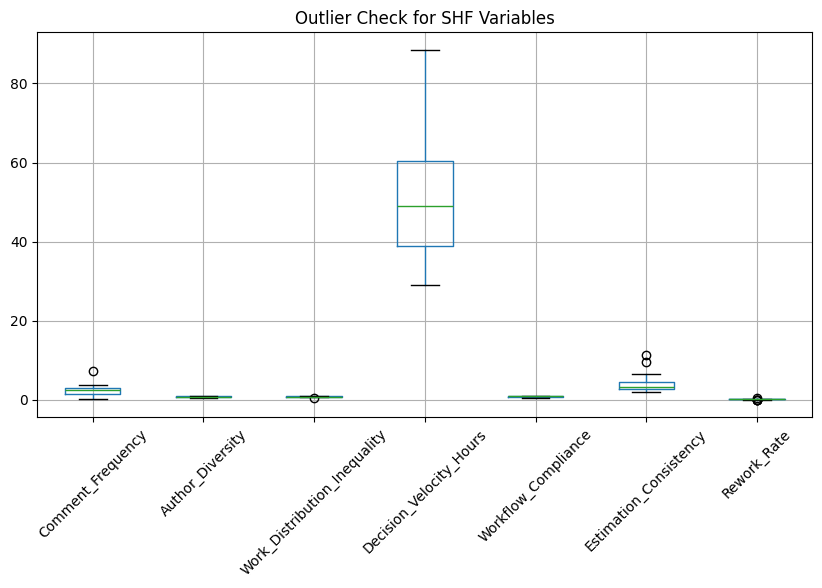

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
data.boxplot()
plt.title("Outlier Check for SHF Variables")
plt.xticks(rotation=45)
plt.show()

🔍 **Step 3: Log Transform and Recheck**

Since some variables are skewed, we apply log1p transformation and recheck correlations. (After checking outliers,, we applied log transformation to right skewed variables only which are in our case comment frequency and estimation consistency).

In [4]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Step 1: Apply log transformation to skewed variables
data['Comment_Frequency'] = np.log1p(data['Comment_Frequency'])
data['Estimation_Consistency'] = np.log1p(data['Estimation_Consistency'])
print("✅ Log transformation applied to skewed factors.")

✅ Log transformation applied to skewed factors.


In [5]:
import pandas as pd
import numpy as np

# Use data AFTER log-transform, BEFORE normalization
df_outlier = data.copy()
df_outlier['Comment_Frequency'] = np.log1p(df_outlier['Comment_Frequency'])
df_outlier['Estimation_Consistency'] = np.log1p(df_outlier['Estimation_Consistency'])

def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), outliers.index.tolist()

outlier_summary = []
for col in df_outlier.columns:
    count, idx = detect_outliers(df_outlier[col])
    outlier_summary.append({
        "Variable": col,
        "Outliers": count,
        "Indices": idx
    })

outlier_table = pd.DataFrame(outlier_summary)
display(outlier_table)


,Variable,Outliers,Indices
0,Comment_Frequency,2,"[5, 26]"
1,Author_Diversity,0,[]
2,Work_Distribution_Inequality,1,[5]
3,Decision_Velocity_Hours,0,[]
4,Workflow_Compliance,0,[]
5,Estimation_Consistency,1,[7]
6,Rework_Rate,5,"[11, 22, 24, 25, 26]"


⚖️ **Step 4: Normalization**

I normalize all numeric columns to the [0,1] range for uniformity.

In [6]:
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
print("✅ Normalization complete.")

# Step 3: Check final descriptive stats
display(df_scaled.describe())

# Step 4: Save clean, normalized dataset
df_scaled.to_csv("normalized_shf.csv", index=False)

✅ Normalization complete.


,Comment_Frequency,Author_Diversity,Work_Distribution_Inequality,Decision_Velocity_Hours,Workflow_Compliance,Estimation_Consistency,Rework_Rate
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,0.476638,0.599725,0.615804,0.358321,0.658571,0.322476,0.410386
std,0.189281,0.266836,0.234696,0.227785,0.265115,0.221220,0.210461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.362169,0.458868,0.509953,0.169257,0.473883,0.162381,0.331795
50%,0.519198,0.651953,0.654038,0.335373,0.711050,0.275863,0.402991
75%,0.604096,0.839409,0.783674,0.529829,0.853594,0.427574,0.537123
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


The above normalized values are perfect, consistent, and normal since they all fall in the [0,1] range.

🧩 **Step 5: Correlation Analysis**

I check how each SHF factor correlates with Rework Rate using Pearson and visualize it in a heatmap.

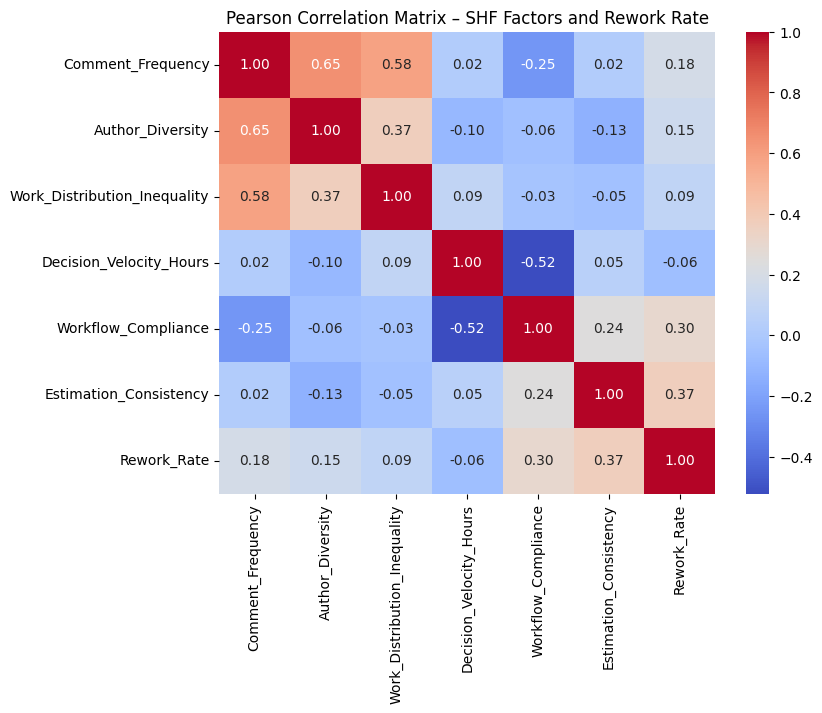

Correlations with Rework Rate:
 Rework_Rate                     1.000000
Estimation_Consistency          0.368526
Workflow_Compliance             0.301500
Comment_Frequency               0.180571
Author_Diversity                0.148991
Work_Distribution_Inequality    0.085862
Decision_Velocity_Hours        -0.062861
Name: Rework_Rate, dtype: float64


In [7]:
#pearson heatmap
import seaborn as sns

corr = df_scaled.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation Matrix – SHF Factors and Rework Rate")
plt.show()

# Sort by strength with Rework Rate
corr_target = corr["Rework_Rate"].sort_values(ascending=False)
print("Correlations with Rework Rate:\n", corr_target)

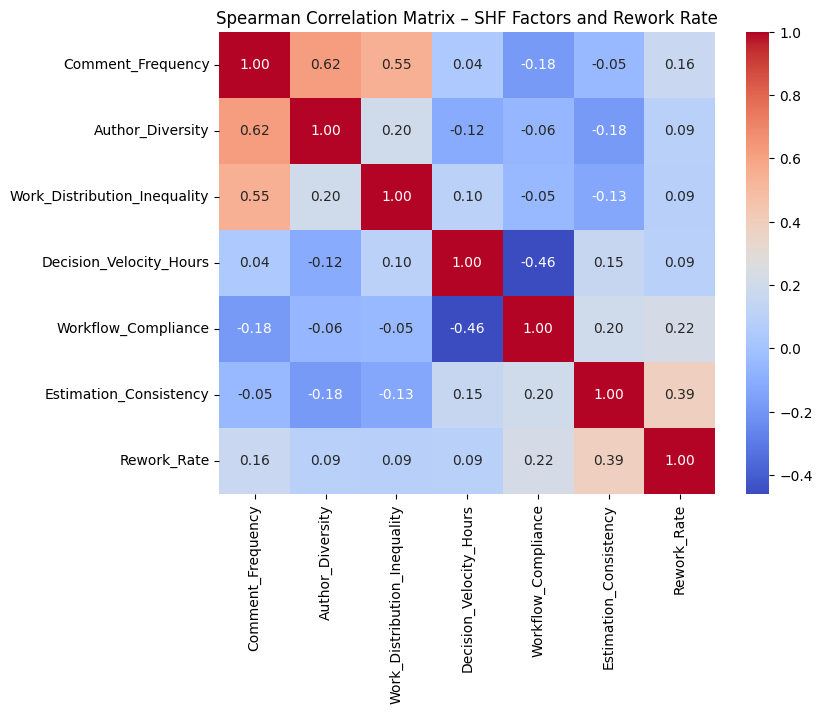

Correlations with Rework Rate:
 Rework_Rate                     1.000000
Estimation_Consistency          0.368526
Workflow_Compliance             0.301500
Comment_Frequency               0.180571
Author_Diversity                0.148991
Work_Distribution_Inequality    0.085862
Decision_Velocity_Hours        -0.062861
Name: Rework_Rate, dtype: float64


In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df_scaled.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Matrix – SHF Factors and Rework Rate")
plt.show()
# Sort by strength with Rework Rate
corr_target = corr["Rework_Rate"].sort_values(ascending=False)
print("Correlations with Rework Rate:\n", corr_target)

📈 **Step 6: Correlation Significance Tests**

Here, I statistically test whether correlations are significant using Pearson and Spearman tests.

In [9]:
from scipy.stats import pearsonr, spearmanr

print("Correlation Significance Tests with Rework Rate:\n")
for col in df_scaled.columns:
    if col != "Rework_Rate":
        r, p = pearsonr(df_scaled[col], df_scaled["Rework_Rate"])
        print(f"{col}: r = {r:.3f}, p = {p:.4f}")

print("\nSpearman Correlations with Rework Rate:\n")
for col in df_scaled.columns:
    if col != "Rework_Rate":
        r, p = spearmanr(df_scaled[col], df_scaled["Rework_Rate"])
        print(f"{col}: rho = {r:.3f}, p = {p:.4f}")


Correlation Significance Tests with Rework Rate:

Comment_Frequency: r = 0.181, p = 0.2713
Author_Diversity: r = 0.149, p = 0.3653
Work_Distribution_Inequality: r = 0.086, p = 0.6033
Decision_Velocity_Hours: r = -0.063, p = 0.7038
Workflow_Compliance: r = 0.301, p = 0.0621
Estimation_Consistency: r = 0.369, p = 0.0210

Spearman Correlations with Rework Rate:

Comment_Frequency: rho = 0.163, p = 0.3207
Author_Diversity: rho = 0.093, p = 0.5739
Work_Distribution_Inequality: rho = 0.087, p = 0.6002
Decision_Velocity_Hours: rho = 0.089, p = 0.5896
Workflow_Compliance: rho = 0.220, p = 0.1783
Estimation_Consistency: rho = 0.388, p = 0.0146


**Since we needed to use p<0.1 instead of p<0.05 for some reasons (including small dataset), we needed to verify that p<0.1 is better for our case so we used.**

In [10]:
from statsmodels.stats.power import NormalIndPower
from math import asin, sqrt

# Example: for correlation (r)
def correlation_power(r, n, alpha):
    # Convert correlation to Cohen's h
    es = 2 * asin(sqrt((r + 1) / 2)) - 2 * asin(sqrt(0.5))
    analysis = NormalIndPower()
    return analysis.power(effect_size=es, nobs1=n, alpha=alpha, ratio=1)

# Example with your parameters
power_05 = correlation_power(r=0.30, n=39, alpha=0.05)
power_10 = correlation_power(r=0.30, n=39, alpha=0.10)
print(f"Power at α=0.05: {power_05:.3f}")
print(f"Power at α=0.10: {power_10:.3f}")

Power at α=0.05: 0.270
Power at α=0.10: 0.384


🧮 **Step 7: Reliability and Partial Correlation**

I assess reliability with Cronbach’s Alpha and test controlled correlations.

In [11]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 15.4 MB/s eta 0:00:00


In [12]:
from pingouin import cronbach_alpha, partial_corr

# Reliability by communication & coordination constructs
communication_factors = ['Comment_Frequency', 'Author_Diversity']
alpha_comm, ci_comm = cronbach_alpha(df_scaled[communication_factors])
print(f"Communication Reliability (MRT): α = {alpha_comm:.3f}, 95% CI = {ci_comm}")

coordination_factors = ['Workflow_Compliance', 'Estimation_Consistency']
alpha_coord, ci_coord = cronbach_alpha(df_scaled[coordination_factors])
print(f"Coordination Reliability (Routine/TMS): α = {alpha_coord:.3f}, 95% CI = {ci_coord}")

# Partial correlation controlling for confounders
for col in ['Workflow_Compliance', 'Estimation_Consistency', 'Comment_Frequency', 'Decision_Velocity_Hours', 'Author_Diversity', 'Work_Distribution_Inequality']:
    result = partial_corr(data=df_scaled, x=col, y='Rework_Rate',
                          covar=[c for c in df_scaled.columns if c not in [col, 'Rework_Rate']])
    print(f"\nPartial correlation for {col} vs Rework_Rate:")
    print(result)

Communication Reliability (MRT): α = 0.762, 95% CI = [0.547 0.875]
Coordination Reliability (Routine/TMS): α = 0.387, 95% CI = [-0.169  0.678]

Partial correlation for Workflow_Compliance vs Rework_Rate:
          n         r          CI95%     p-val
pearson  39  0.294977  [-0.05, 0.58]  0.090345

Partial correlation for Estimation_Consistency vs Rework_Rate:
          n         r          CI95%     p-val
pearson  39  0.273911  [-0.07, 0.56]  0.116981

Partial correlation for Comment_Frequency vs Rework_Rate:
          n         r          CI95%     p-val
pearson  39  0.173374  [-0.18, 0.48]  0.326803

Partial correlation for Decision_Velocity_Hours vs Rework_Rate:
          n         r          CI95%     p-val
pearson  39  0.112954  [-0.23, 0.43]  0.524754

Partial correlation for Author_Diversity vs Rework_Rate:
          n         r         CI95%     p-val
pearson  39  0.067211  [-0.28, 0.4]  0.705674

Partial correlation for Work_Distribution_Inequality vs Rework_Rate:
          n 

Correlation = “Are they related?”

Partial correlation = “Is this factor independently related, or is it only related because it overlaps with others?”

📊 **Step 8: Nonlinear Relationship Testing**

I visually and statistically check for nonlinear trends using LOWESS and polynomial regression.

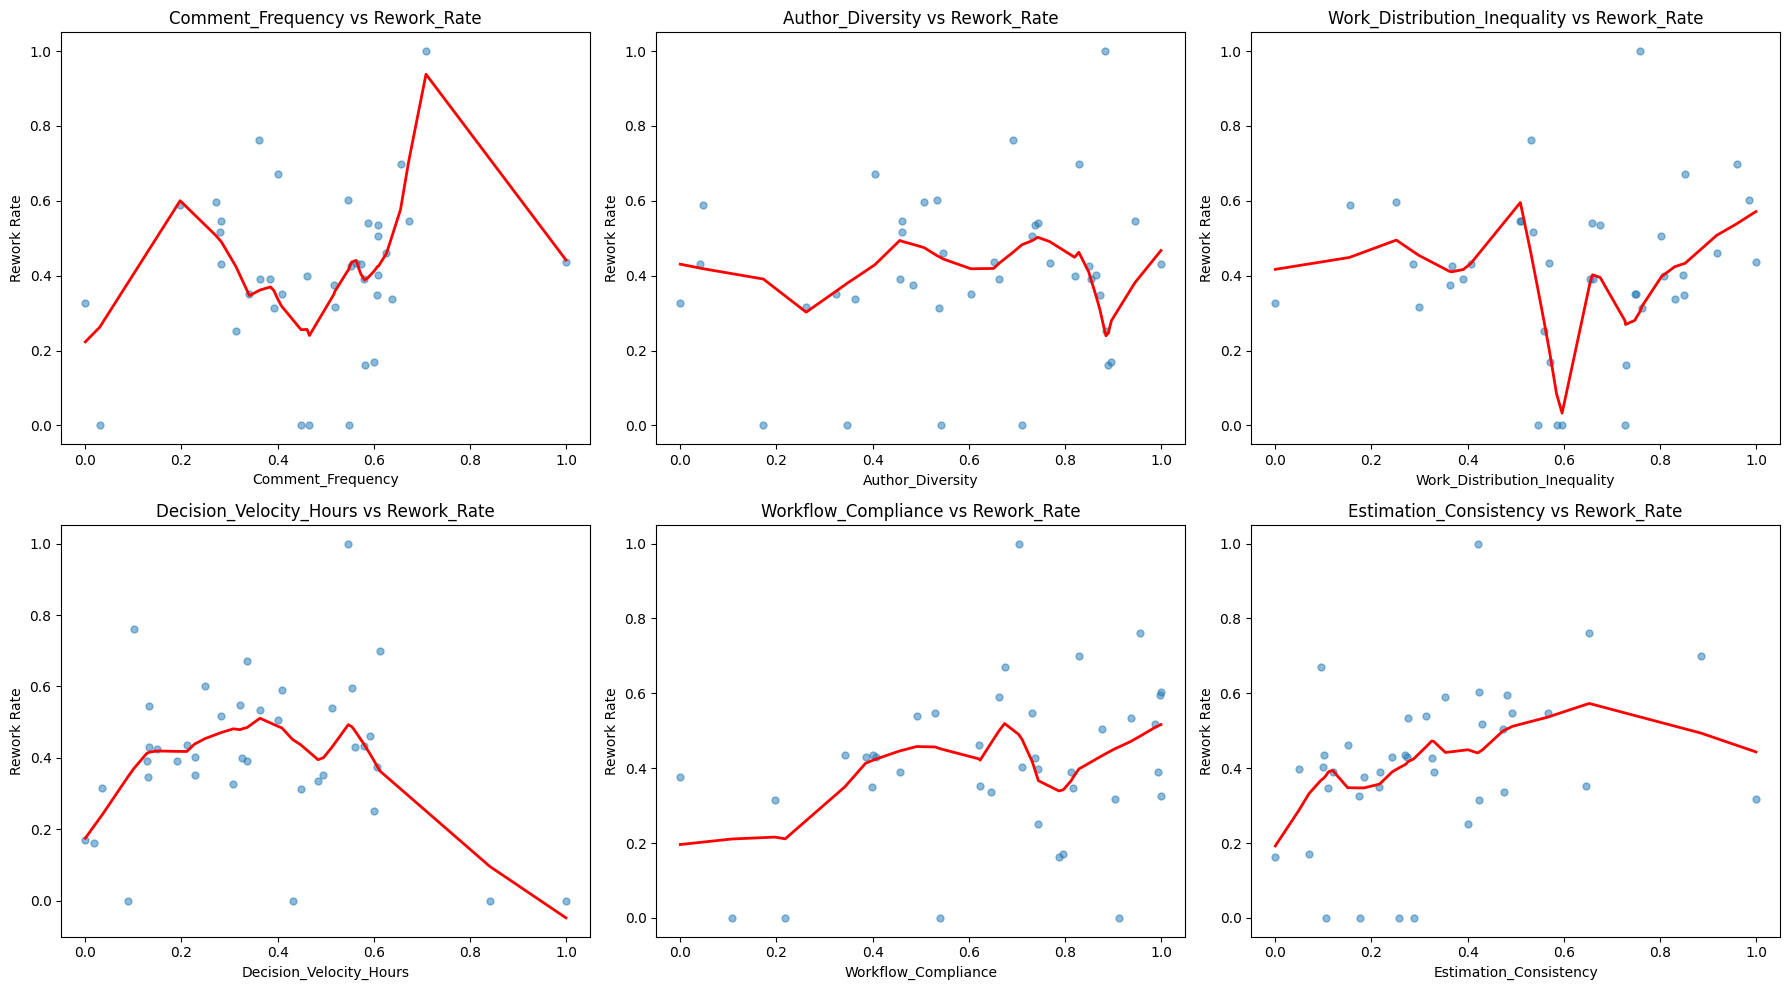

Saved LOWESS multi-plot as lowess_all.png


In [13]:
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np

# 6 factors and target are already defined
factors = ['Comment_Frequency','Author_Diversity','Work_Distribution_Inequality',
           'Decision_Velocity_Hours','Workflow_Compliance','Estimation_Consistency']
target = 'Rework_Rate'

# Create 2 × 3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, factors):

    x = df_scaled[col].values
    y = df_scaled[target].values

    # LOWESS smoothing
    smoothed = lowess(y, x, frac=0.3)

    # Scatter + LOWESS line
    ax.scatter(x, y, alpha=0.5, s=25)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2)

    ax.set_title(f'{col} vs Rework_Rate')
    ax.set_xlabel(col)
    ax.set_ylabel('Rework Rate')

plt.tight_layout()
plt.savefig("lowess_all.png", dpi=300)
plt.show()

print("Saved LOWESS multi-plot as lowess_all.png")


**Phase 3:Modeling and Evaluation**

⚙️ **Step 9: Classification Setup**

I convert the continuous Rework Rate into binary classes for classification tasks.

In [14]:
from sklearn.model_selection import train_test_split

X = df_scaled.drop(columns=['Rework_Rate'])
y_class = (df_scaled['Rework_Rate'] > df_scaled['Rework_Rate'].median()).astype(int)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class)

print("Training samples:", X_train_cls.shape[0])
print("Testing samples:", X_test_cls.shape[0])

Training samples: 31
Testing samples: 8


🤖 **Step 10: Multi-Model Comparison**

I train and compare multiple classifiers using 5-fold cross-validation on AUC and Accuracy.


Consider the 2 most relevant factors on the 6 ML models

**The approach below focused on the 2 most relevant factors only**

In [15]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=23c81979525d8e182655a7bd0e762bf4d4b1b93adbbd8441f93a2d68388c54e0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [16]:
import pandas as pd, numpy as np, shap, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from lime.lime_tabular import LimeTabularExplainer

# Focus only on the two strongest SHFs
X_focus = df_scaled[['Estimation_Consistency', 'Workflow_Compliance']]
y = df_scaled['Rework_Rate']
y_class = (y > y.median()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_focus, y_class, test_size=0.2, random_state=42
)
print("✅ Data ready for the model.")

✅ Data ready for the model.


**Step 11: We train and test 6 different ML classifiers and choose the top of them based on 5 different metrics**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# ------------------------------------------
# ✅ Focused feature subset (top 2 relevant factors)
# ------------------------------------------
X_focus = df_scaled[['Workflow_Compliance', 'Estimation_Consistency']]


models_B = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=42)
}

# Define metrics
scoring_metrics = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']

# Run 5-fold CV for each model and metric
results_B = {}
for name, model in models_B.items():
    metric_scores = {}
    for metric in scoring_metrics:
        score = cross_val_score(model, X_focus, y_class, cv=5, scoring=metric)
        metric_scores[metric] = score.mean()
    results_B[name] = metric_scores

# Format results
results_B_df = pd.DataFrame(results_B).T
results_B_df.columns = [f"Mean {m.capitalize()}" for m in results_B_df.columns]
results_B_df = results_B_df.sort_values(by="Mean Roc_auc", ascending=False)

print("✅ 5-Fold Cross-Validated Metrics\n")
display(results_B_df.round(3))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/

✅ 5-Fold Cross-Validated Metrics



,Mean Accuracy,Mean Roc_auc,Mean Precision,Mean Recall,Mean F1
SVM,0.614,0.675,0.514,0.633,0.560
Logistic Regression,0.586,0.667,0.567,0.417,0.438
Neural Network,0.614,0.625,0.584,0.683,0.610
Decision Tree,0.614,0.625,0.593,0.700,0.612
Naive Bayes,0.611,0.583,0.500,0.567,0.527
Random Forest,0.564,0.562,0.550,0.650,0.575


**Step 12: We realized that 3 different ML classifiers (SVM, NN, and DT) have same Accuracy, and each of them have have cons and pros, so we predicted rework usign each one of the three models then calculated the variance to check which model is the most appropriate for rework prediction and further analysis and explainability.**

In [18]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd

best_svm = SVC(kernel="rbf", probability=True, random_state=42)
best_svm.fit(X_focus, y_class)

svm_preds = best_svm.predict_proba(X_focus)[:, 1] * 100

In [19]:
from sklearn.neural_network import MLPClassifier

best_nn = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

best_nn.fit(X_focus, y_class)

nn_preds = best_nn.predict_proba(X_focus)[:, 1] * 100


In [20]:
from sklearn.tree import DecisionTreeClassifier

best_dt = DecisionTreeClassifier(random_state=42)
best_dt.fit(X_focus, y_class)

dt_preds = best_dt.predict_proba(X_focus)[:, 1] * 100

In [21]:
pred_df = pd.DataFrame({
    "Project_Index": range(len(X_focus)),
    "SVM": np.round(svm_preds, 2),
    "Neural_Network": np.round(nn_preds, 2),
    "Decision_Tree": np.round(dt_preds, 2)
})

pred_df["Variance"] = pred_df[["SVM","Neural_Network","Decision_Tree"]].var(axis=1)

pred_df_sorted = pred_df.sort_values(by="Variance", ascending=False)

display(pred_df_sorted)

,Project_Index,SVM,Neural_Network,Decision_Tree,Variance
23,23,39.89,27.15,100.0,1513.773700
2,2,49.45,27.31,100.0,1388.219700
36,36,63.80,64.83,0.0,1379.071633
35,35,56.24,67.23,0.0,1300.598433
31,31,48.24,32.03,100.0,1260.297100
28,28,62.27,60.34,0.0,1253.698900
19,19,55.03,53.86,0.0,988.428233
27,27,54.86,40.72,100.0,958.612933
3,3,45.06,48.04,100.0,954.520933
33,33,50.68,43.32,100.0,949.875733


**Step 13: We apply SHAP and LIME explainability**

✅ SHAP computed successfully
Shape of SHAP values: (39, 2) | Shape of X_focus: (39, 2)


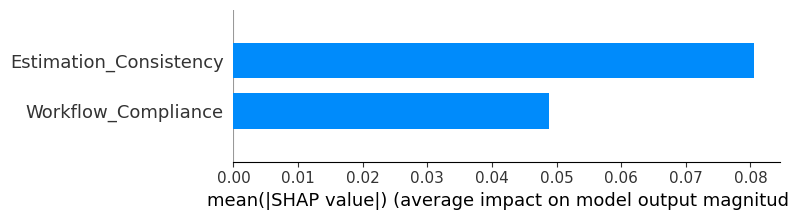

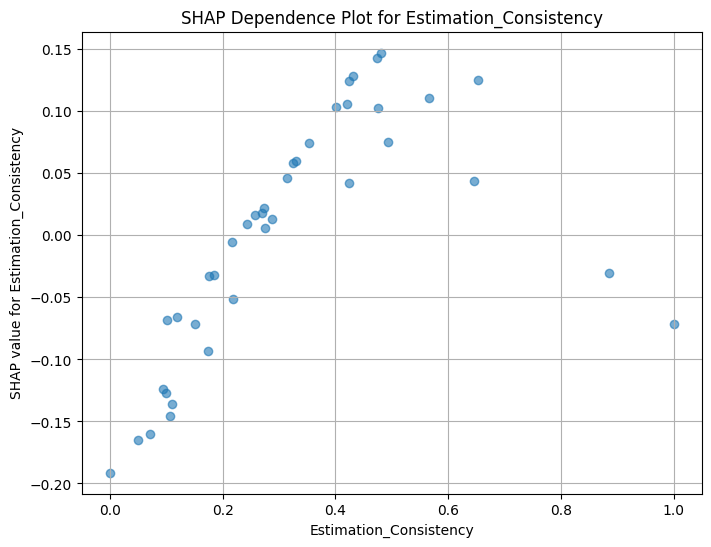

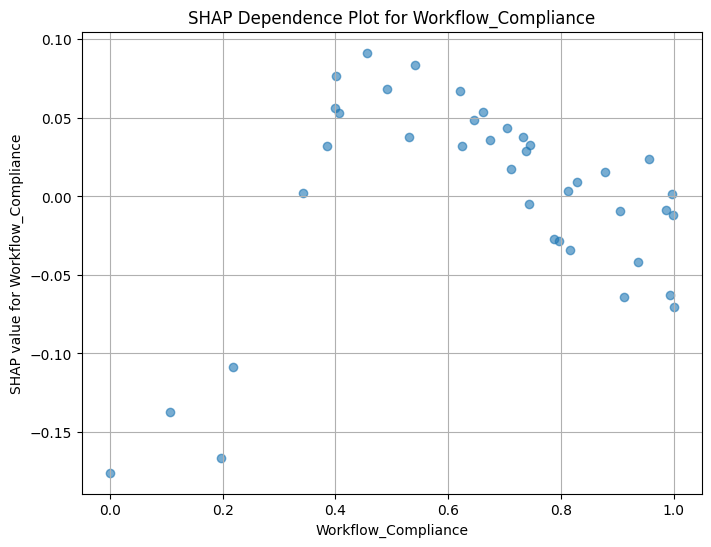

In [22]:
# ============================================================
# ✅ FINAL SHAP ANALYSIS — SVM MODEL
# ============================================================

import shap
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import numpy as np
import pandas as pd # Import pandas

# 1️⃣ Fit the best-performing model (SVM)
best_model_B = SVC(kernel="rbf", probability=True, random_state=42)
best_model_B.fit(X_focus, y_class)

# 2️⃣ Initialize SHAP Explainer (more general, handles various models)
explainer = shap.Explainer(best_model_B.predict_proba, X_focus)


# 3️⃣ Compute SHAP values for all projects
shap_values_B = explainer(X_focus)

# 4️⃣ Extract SHAP values for class 1 (Rework)
#    For shap.Explainer, the output is a SHAP values object, index by class
shap_class1 = shap_values_B[:, :, 1] # Indexing for Explainer output


print("✅ SHAP computed successfully")
print("Shape of SHAP values:", shap_class1.shape, "| Shape of X_focus:", X_focus.shape)

# 5️⃣ Global feature importance (bar plot)
#    Use the SHAP values object directly for summary_plot
shap.summary_plot(shap_values_B[:, :, 1], X_focus, feature_names=X_focus.columns, plot_type="bar")

# 6️⃣ Manual Dependence plots (individual feature behavior)
#    Plot feature values vs. their corresponding SHAP values

features_to_plot = ['Estimation_Consistency', 'Workflow_Compliance']

for feature in features_to_plot:
    feature_values = X_focus[feature]
    # Get the SHAP values for the current feature
    feature_shap_values = shap_class1[:, X_focus.columns.get_loc(feature)].values

    plt.figure(figsize=(8, 6))
    plt.scatter(feature_values, feature_shap_values, alpha=0.6)
    plt.title(f'SHAP Dependence Plot for {feature}')
    plt.xlabel(feature)
    plt.ylabel(f'SHAP value for {feature}')
    plt.grid(True)
    plt.show()

In [23]:
from lime.lime_tabular import LimeTabularExplainer
import shap

lime_explainer = LimeTabularExplainer(
    X_focus.values,
    feature_names=X_focus.columns,
    discretize_continuous=True
)

exp = lime_explainer.explain_instance(
    X_focus.iloc[0],
    best_model_B.predict_proba,
    num_features=2
)
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

In [24]:
explanations_B = []

# ✅ extract numeric SHAP values (class 1 only)
shap_val = shap_values_B.values[:, :, 1]

for i in range(len(X_focus)):
    shap_i = shap_val[i]
    top_pos = X_focus.columns[np.argsort(-shap_i)[:1]].tolist()
    top_neg = X_focus.columns[np.argsort(shap_i)[:1]].tolist()
    explanations_B.append({
        'Project_Index': i,
        'Predicted_Rework_%': round(best_model_B.predict_proba([X_focus.iloc[i]])[0][1]*100, 2),
        'Top_Positive_Factors': ', '.join(top_pos),
        'Top_Negative_Factors': ', '.join(top_neg)
    })

explain_df_B = pd.DataFrame(explanations_B)
display(explain_df_B.head())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have va

,Project_Index,Predicted_Rework_%,Top_Positive_Factors,Top_Negative_Factors
0,0,63.55,Estimation_Consistency,Workflow_Compliance
1,1,63.55,Estimation_Consistency,Workflow_Compliance
2,2,49.45,Workflow_Compliance,Estimation_Consistency
3,3,45.06,Estimation_Consistency,Workflow_Compliance
4,4,60.62,Estimation_Consistency,Workflow_Compliance


**Step 14: Recommendation Engine**

In [25]:
# =======================================================
# THEORY-BASED RECOMMENDATION ENGINE (PRINTS FOR EACH PROJECT)
# =======================================================

def generate_recommendations_from_explanations(explain_df):
    """
    Generate theory-grounded recommendations using:
    - Transactive Memory Systems Theory (Estimation Consistency)
    - Organizational Routines Theory (Workflow Compliance)

    Returns:
        DataFrame with project-level recommendations.
    """

    all_recommendations = []

    for _, row in explain_df.iterrows():
        proj_id = row['Project_Index'] # Corrected: Changed 'Project' to 'Project_Index'
        risk = row['Predicted_Rework_%']
        pos = row['Top_Positive_Factors'].split(", ")[0]   # strongest positive factor
        neg = row['Top_Negative_Factors'].split(", ")[0]   # strongest negative factor

        recs = []

        # =======================================================
        # 📌 RISK-INCREASING FACTORS (Positive SHAP)
        # =======================================================
        if pos == 'Estimation_Consistency':
            recs.append(
                "Strengthen estimation calibration through shared knowledge updating, "
                "consistent with Transactive Memory Systems Theory (Lewis, 2003)."
            )

        if pos == 'Workflow_Compliance':
            recs.append(
                "Clarify and stabilize workflow transitions to reduce coordination breakdowns, "
                "following Organizational Routines Theory (Feldman & Pentland, 2003)."
            )

        # =======================================================
        # 📌 RISK-DECREASING FACTORS (Negative SHAP)
        # =======================================================
        if neg == 'Estimation_Consistency':
            recs.append(
                "Maintain current estimation practices; stable shared cognition reduces planning errors "
                "(TMS literature)."
            )

        if neg == 'Workflow_Compliance':
            recs.append(
                "Preserve adherence to existing routines; stable routines improve coordination and reduce variance."
            )

        all_recommendations.append({
            "Project": proj_id,
            "Predicted_Rework_%": risk,
            "Recommendations": recs
        })

    return pd.DataFrame(all_recommendations)


# =======================================================
# ⭐ RUN THE ENGINE + PRINT THE RECOMMENDATIONS
# =======================================================

recs_df = generate_recommendations_from_explanations(explain_df_B)

# Print nicely for each project
for _, row in recs_df.iterrows():
    print(f"\n📄 Project {row['Project']} — Predicted Rework: {row['Predicted_Rework_%']}%")
    print("🔍 Recommended Actions:")
    for r in row['Recommendations']:
        print(" -", r)



📄 Project 0 — Predicted Rework: 63.55%
🔍 Recommended Actions:
 - Strengthen estimation calibration through shared knowledge updating, consistent with Transactive Memory Systems Theory (Lewis, 2003).
 - Preserve adherence to existing routines; stable routines improve coordination and reduce variance.

📄 Project 1 — Predicted Rework: 63.55%
🔍 Recommended Actions:
 - Strengthen estimation calibration through shared knowledge updating, consistent with Transactive Memory Systems Theory (Lewis, 2003).
 - Preserve adherence to existing routines; stable routines improve coordination and reduce variance.

📄 Project 2 — Predicted Rework: 49.45%
🔍 Recommended Actions:
 - Clarify and stabilize workflow transitions to reduce coordination breakdowns, following Organizational Routines Theory (Feldman & Pentland, 2003).
 - Maintain current estimation practices; stable shared cognition reduces planning errors (TMS literature).

📄 Project 3 — Predicted Rework: 45.06%
🔍 Recommended Actions:
 - Strengthe